In [1]:
from astropy.table import Table

In [2]:
test_cat = Table.read("./testobjekte.fits")


Initialising Object 1/12


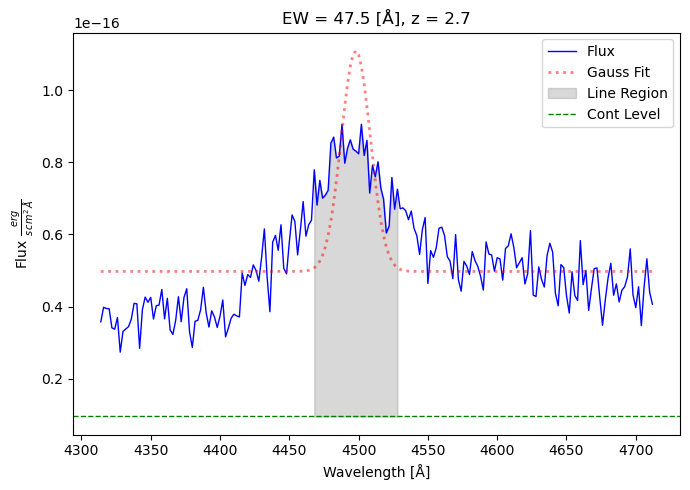

done

Initialising Object 2/12


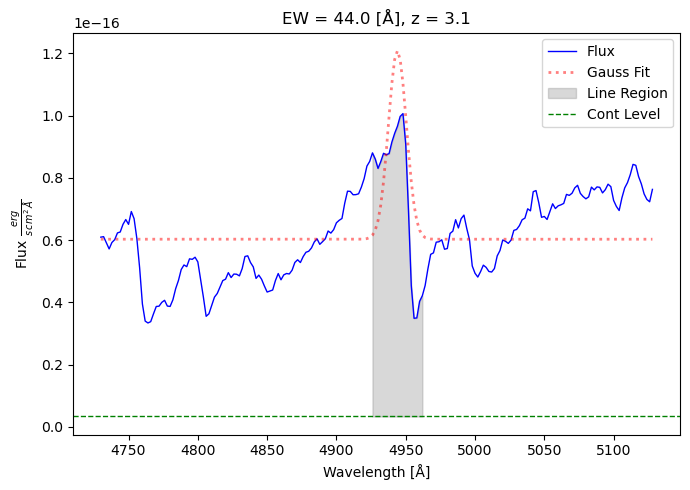

done

Initialising Object 3/12


/data/hetdex/u/bgrashey/git/Master/notebooks/tools/EW.py:347: RuntimeWarning: divide by zero encountered in scalar divide
  rel_err_sq = (self.flux_err / self.peak_flux)**2 + (self.cont_err / self.cont)**2
/data/hetdex/u/bgrashey/git/Master/notebooks/tools/EW.py:348: RuntimeWarning: invalid value encountered in scalar multiply
  err = ew_obs * np.sqrt(rel_err_sq)


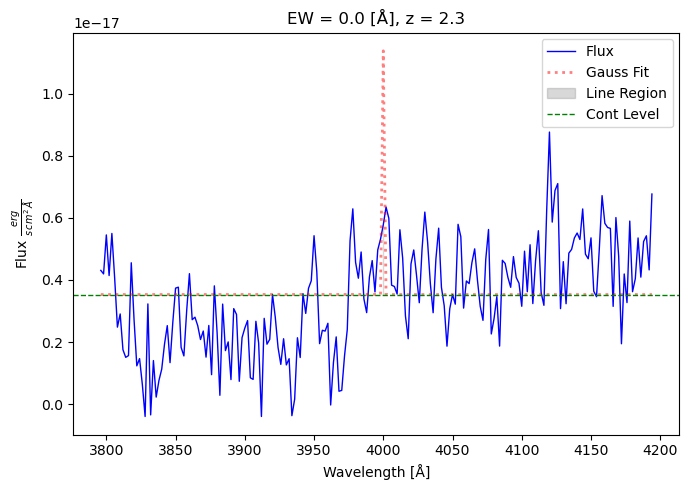

done

Initialising Object 4/12


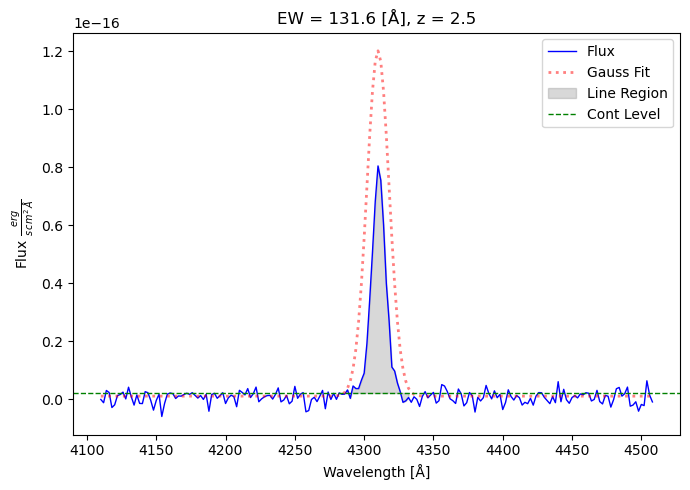

done

Initialising Object 5/12


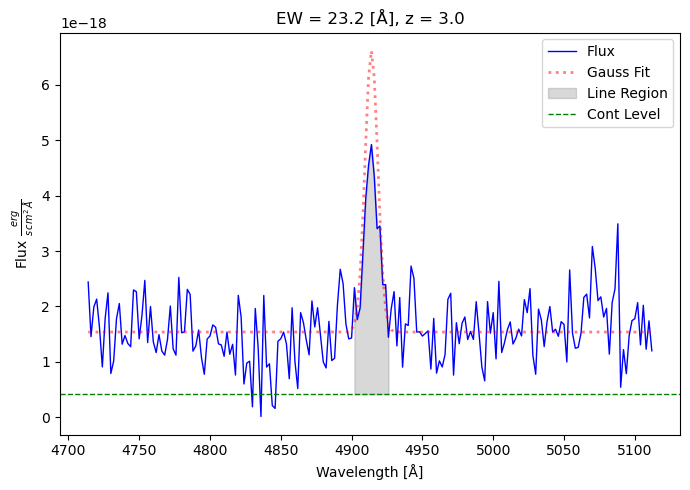

done

Initialising Object 6/12


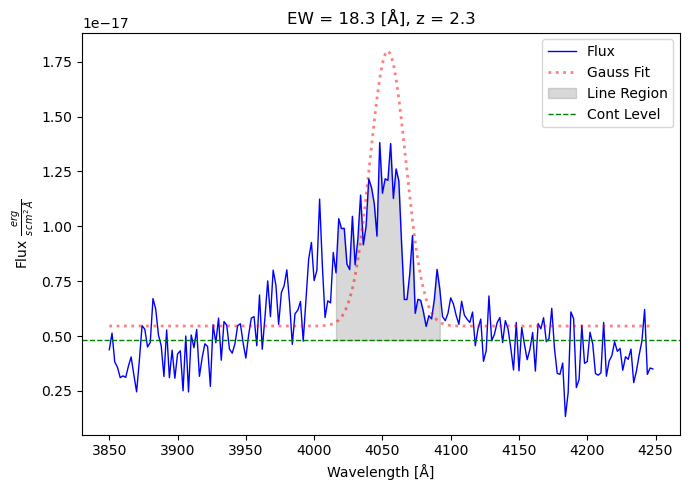

done

Initialising Object 7/12


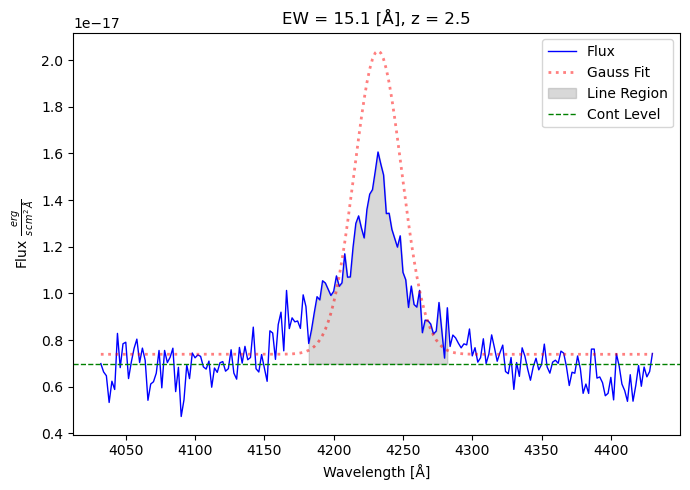

done

Initialising Object 8/12


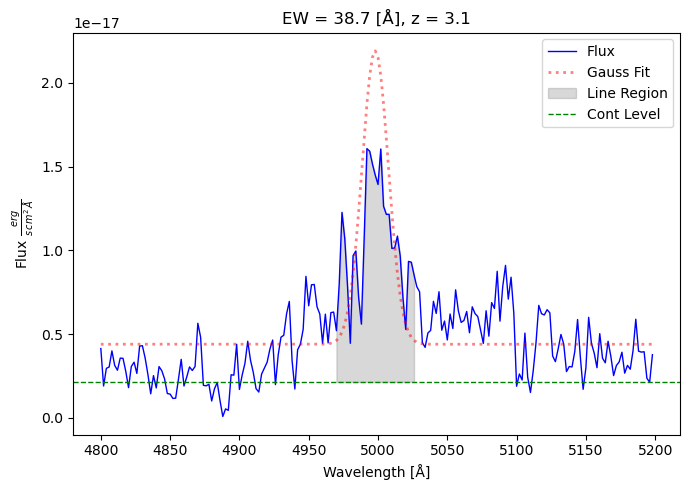

done

Initialising Object 9/12


/data/hetdex/u/bgrashey/git/Master/notebooks/tools/EW.py:347: RuntimeWarning: divide by zero encountered in scalar divide
  rel_err_sq = (self.flux_err / self.peak_flux)**2 + (self.cont_err / self.cont)**2
/data/hetdex/u/bgrashey/git/Master/notebooks/tools/EW.py:348: RuntimeWarning: invalid value encountered in scalar multiply
  err = ew_obs * np.sqrt(rel_err_sq)


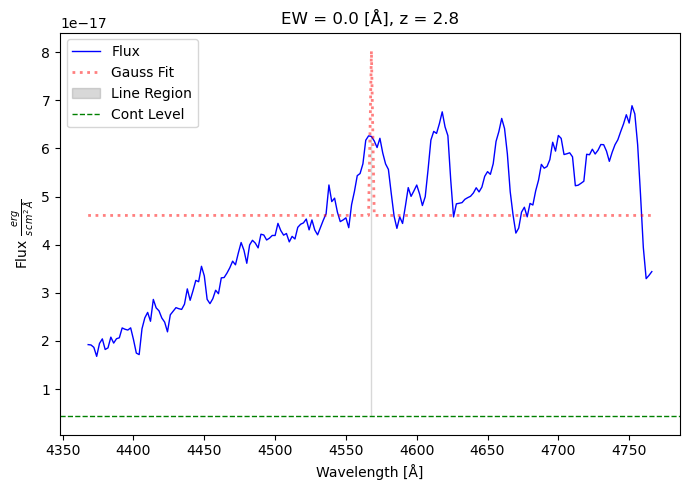

done

Initialising Object 10/12


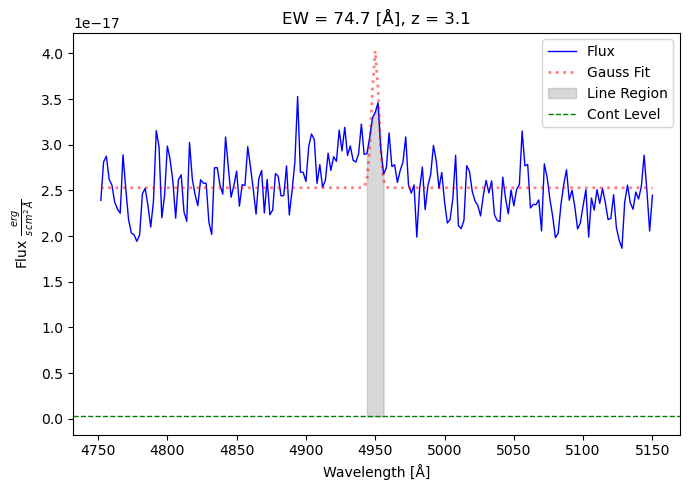

done

Initialising Object 11/12


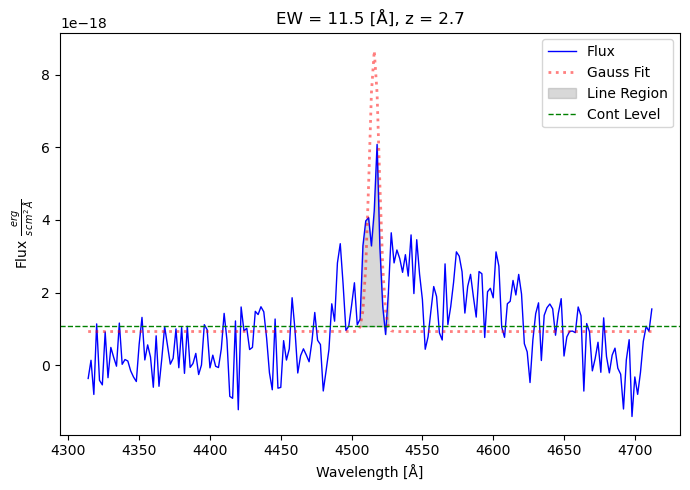

done

Initialising Object 12/12


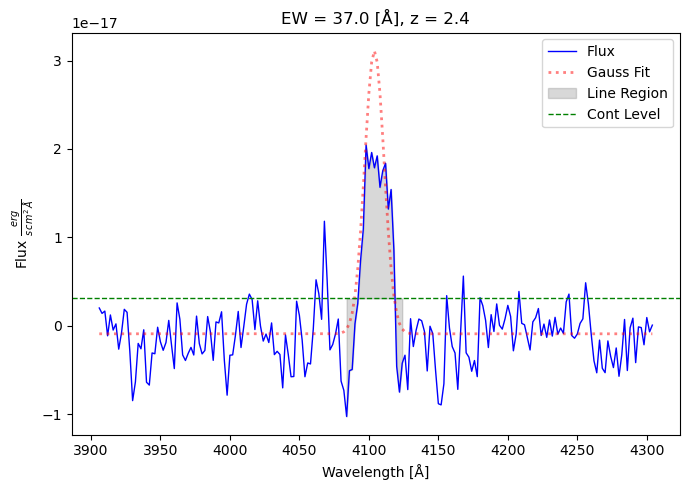

done


ModuleNotFoundError: No module named 'line_classifier'

In [3]:
COL_RA  = "ra_vdfi"
COL_DEC = "dec_vdfi"
COL_z   = "z_vdfi"
table_path = "./testobjekte.fits"

from astropy.table import Table
import os
import numpy as np
from tools.EW import Measurements
from astropy.io import fits
from astropy.coordinates import SkyCoord

# catalog:
tbl = Table.read(table_path)
Catalog = tbl.to_pandas()
Catalog = Catalog.reset_index(drop=True)

#directory = "/data/hetdex/u/mxhf/VDFI/VirusDeep/stackmf/ssa22_fullfp/"
#file_stack = "ssa22_fullfp_stack.fits"
#stack = os.path.join(directory, file_stack)
stack = "/data/hetdex/u/bgrashey/cubes/ssa22_fullfp_stack.fits"
cube = fits.open(stack)
data = cube[0].section
header = cube[0].header

hsc_file = "/data/hetdex/u/mxhf/VDFI/joint/ssa22_hsc_pdr3_wide.fits"
with fits.open(hsc_file) as hdul:
    hsc_df = Table(hdul[1].data).to_pandas()
hsc_coords = SkyCoord(ra=hsc_df["ra"].values, 
                      dec=hsc_df["dec"].values, 
                      unit="deg", frame="icrs")        

# Neue Spalten als Listen initialisieren
new_cols = {
    "REDSHIFT": [], "EW": [], "EW_OBS": [], "EW_ERR": [],
    "FLUX": [], "FLUX_ERR": [], "CONT": [], "CONT_ERR": [],
    "FWHM": [], "SNR": []
}

N = 0 #len(Catalog[COL_RA])
for n in range(N):
    print(f"\nInitialising Object {n+1}/{N}")
    
    try:
        coords = (
            Catalog[COL_RA][n],
            Catalog[COL_DEC][n],
            Catalog[COL_z][n]
        )
        
        meas = Measurements(data, header, coords, hsc_df, hsc_coords)
        EW_OBS, EW, EW_ERR, F, F_ERR, C, C_ERR, z, fwhm, snr = meas.measure_ew()
        
        new_cols["REDSHIFT"].append(z)
        new_cols["EW"].append(EW)
        new_cols["EW_OBS"].append(EW_OBS)
        new_cols["EW_ERR"].append(EW_ERR)
        new_cols["FLUX"].append(F)
        new_cols["FLUX_ERR"].append(F_ERR)
        new_cols["CONT"].append(C)
        new_cols["CONT_ERR"].append(C_ERR)
        new_cols["FWHM"].append(fwhm)
        new_cols["SNR"].append(snr)
        
        meas.plot_ew(show=True)
        
        print("done")
    
    except Exception as e:
        print(f"Object {n} failed: {e}")
        for key in new_cols:
            new_cols[key].append(np.nan)
            
    

# Neue Spalten an den originalen Katalog hängen
for col_name, values in new_cols.items():
    tbl[col_name] = np.array(values, dtype="f8")

cube.close()

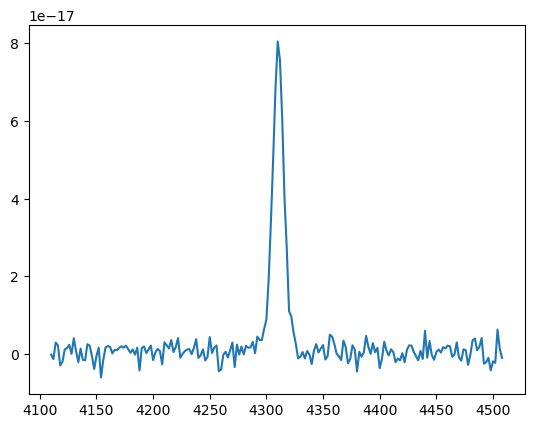

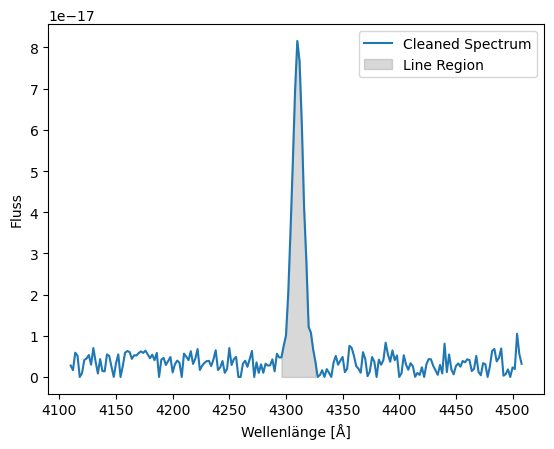

In [38]:
from tools.EW import Measurements as meas

test_objekt = 4
test_idx = test_objekt - 1 

spalte = test_cat[test_idx]

coords = (spalte["ra_vdfi"], spalte["dec_vdfi"], spalte["z_vdfi"])

obj = meas(data, header, coords, hsc_df, hsc_coords)

# get the spectrum
wave, spec = obj.get_spectrum()

# show the spectrum
import matplotlib.pyplot as plt

plt.plot(wave, spec)
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import white_tophat
from astropy.stats import biweight_midvariance, biweight_location

# 1. Spektrum & Fensterbreite definieren
line_width_pixels = 10
window_size = line_width_pixels * 3 

# 2. White Top-Hat anwenden
cleaned_spectrum = white_tophat(spec, size=window_size)

# 3. Rauschniveau & Thresholds berechnen
robust_var = biweight_midvariance(cleaned_spectrum)
sigma_noise = np.sqrt(robust_var)
baseline = biweight_location(cleaned_spectrum)

threshold_boundary = baseline + 1.0 * sigma_noise
threshold_detection = baseline + 5.0 * sigma_noise

# 4. Peak & Boundaries suchen
peak_idx = np.argmax(cleaned_spectrum)

below_threshold_indices = np.where(cleaned_spectrum <= threshold_boundary)[0]

left_candidates = below_threshold_indices[below_threshold_indices < peak_idx]
left_idx = left_candidates.max() if len(left_candidates) > 0 else 0

right_candidates = below_threshold_indices[below_threshold_indices > peak_idx]
right_idx = right_candidates.min() if len(right_candidates) > 0 else len(cleaned_spectrum) - 1

x_start = wave[left_idx]
x_end = wave[right_idx]

# 5. Plotten mit Füllung
x_sub = wave[left_idx : right_idx + 1]
y_sub = cleaned_spectrum[left_idx : right_idx + 1]

plt.plot(wave, cleaned_spectrum, label='Cleaned Spectrum')
plt.fill_between(x_sub, y_sub, y2=0, color='grey', alpha=0.3, label='Line Region')
plt.xlabel('Wellenlänge [Å]')
plt.ylabel('Fluss')
plt.legend()
plt.show()